<a href="https://colab.research.google.com/github/PabloBenitezR/Aprendizaje-Profundo/blob/main/4_Reconocimiento_de_comandos_de_voz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4. Reconocimiento de comandos de voz
#### Comparar tres arquitecturas de deep learning para la tarea de clasificacion de comandos de voz usando el dataset Speech Commands:
#
#### - Red recurrente (RNN con LSTM)
#### - Red convolucional 1D (CNN 1D)
#### - Red convolucional 2D (CNN 2D)
#
#### Las entradas seran MFCCs (coeficientes cepstrales en la escala de Mel) extraidos de cada archivo de audio.

instalación de librerías necesarias

In [3]:
!pip install tensorflow tensorflow-datasets librosa scikit-learn matplotlib


### importar librerías y definir configuración

 se definen parametros globales como la tasa de muestreo, la duracion esperada de cada audio y el número de coeficientes MFCC.

In [4]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# parametros
SEED = 42
SAMPLE_RATE = 16000
DURACION = 1
N_MFCC = 40

`tensorflow_datasets` para descargar y cargar el conjunto de datos Speech Commands

se filtraran solo algunas clases como 'yes', 'no', 'up'.

In [5]:
# data
import tensorflow_datasets as tfds
ds, ds_info = tfds.load("speech_commands", split='train', with_info=True)

etiquetas = ds_info.features['label'].names
print("Etiquetas:", etiquetas)

CLASES_OBJETIVO = ['yes', 'no', 'up', 'down', 'left', 'right']

Etiquetas: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', '_silence_', '_unknown_']


caracteristicas MFCC

cada audio se convierte en una secuencia de MFCCs, que representan el contenido espectral del audio

se normaliza la duracion de cada audio mediante padding o truncamiento.

In [6]:
def extraer_mfcc(audio, sample_rate):
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=N_MFCC)
    return mfccs.T

X = []
y = []

for ejemplo in tfds.as_numpy(ds):
    etiqueta = ejemplo['label']
    if etiquetas[etiqueta] not in CLASES_OBJETIVO:
        continue

    audio = ejemplo['audio']
    audio = audio.astype(np.float32) / np.max(np.abs(audio))


    if len(audio) < SAMPLE_RATE:
        audio = np.pad(audio, (0, SAMPLE_RATE - len(audio)))
    else:
        audio = audio[:SAMPLE_RATE]

    mfcc = extraer_mfcc(audio, SAMPLE_RATE)
    X.append(mfcc)
    y.append(CLASES_OBJETIVO.index(etiquetas[etiqueta]))

Preparar los datos

se crea un arreglo con las secuencias MFCC extraidas y las etiquetas correspondientes

se asegura que todas las secuencias tengan la misma longitud para poder entrenar los modelos.

se separan los datos en conjunto de entrenamiento y de validacion.

In [7]:
X = np.array(X)
y = np.array(y)

print("Forma de X:", X.shape)

max_len = max([x.shape[0] for x in X])
X_relleno = np.array([np.pad(x, ((0, max_len - x.shape[0]), (0,0))) for x in X])

# entrenamiento/validacion
X_train, X_val, y_train, y_val = train_test_split(X_relleno, y, test_size=0.2, stratify=y, random_state=SEED)

X_train_2d = X_train[..., np.newaxis]
X_val_2d = X_val[..., np.newaxis]


Forma de X: (18496, 32, 40)


se definen tres funciones para crear modelos basados en:

 - **RNN**: usa una capa LSTM para procesar la secuencia de MFCCs.
 - **CNN 1D**: usa capas convolucionales 1D sobre la secuencia temporal.
 - **CNN 2D**: trata la entrada como una imagen  y aplica convoluciones 2D.

In [8]:
# ----------------------
# MODELO RNN
# ----------------------
def construir_rnn(forma_entrada, num_clases):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=forma_entrada),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_clases, activation='softmax')
    ])
    return modelo

# ----------------------
# MODELO CNN 1D
# ----------------------
def construir_cnn1d(forma_entrada, num_clases):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=forma_entrada),
        tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_clases, activation='softmax')
    ])
    return modelo

# ----------------------
# MODELO CNN 2D
# ----------------------
def construir_cnn2d(forma_entrada, num_clases):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=forma_entrada),
        tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_clases, activation='softmax')
    ])
    return modelo

se entrena cada modelo durante 10 epocas y se grafican las perdidas de entrenamiento y validacion

se genera un reporte de clasificacion y una matriz de confusion para analizar el rendimiento del modelo sobre las clases objetivo.

Epoch 1/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.3459 - loss: 1.5909 - val_accuracy: 0.5311 - val_loss: 1.1811
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5554 - loss: 1.1150 - val_accuracy: 0.6127 - val_loss: 1.0075
Epoch 3/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6512 - loss: 0.9262 - val_accuracy: 0.6630 - val_loss: 0.8945
Epoch 4/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.7043 - loss: 0.8081 - val_accuracy: 0.7189 - val_loss: 0.8029
Epoch 5/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7615 - loss: 0.6596 - val_accuracy: 0.7632 - val_loss: 0.6689
Epoch 6/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8043 - loss: 0.5608 - val_accuracy: 0.7841 - val_loss: 0.6113
Epoch 7/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8367 - loss: 0.4690 - val_accuracy: 0.8008 - val_loss: 0.5634
Epoch 8/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8488 - loss: 0.4275 - val_a

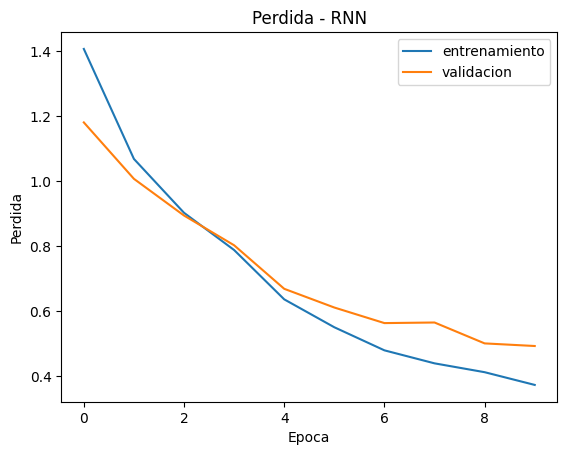

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Resultados - RNN
              precision    recall  f1-score   support

         yes       0.88      0.90      0.89       646
          no       0.77      0.78      0.77       626
          up       0.89      0.85      0.87       590
        down       0.75      0.80      0.77       627
        left       0.85      0.73      0.79       607
       right       0.87      0.92      0.89       604

    accuracy                           0.83      3700
   macro avg       0.83      0.83      0.83      3700
weighted avg       0.83      0.83      0.83      3700

[[582  15   1  12  28   8]
 [ 11 487  19  91  10   8]
 [  3  25 502  27  18  15]
 [  9  74  25 504   6   9]
 [ 51  24  15  30 445  42]
 [  6  10   5  12  16 555]]
Epoch 1/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4121 - loss: 7.7404 - val_accuracy: 0.7032 - val_loss: 1.0976
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7637 - loss: 0.8002 - val_accuracy: 0.748

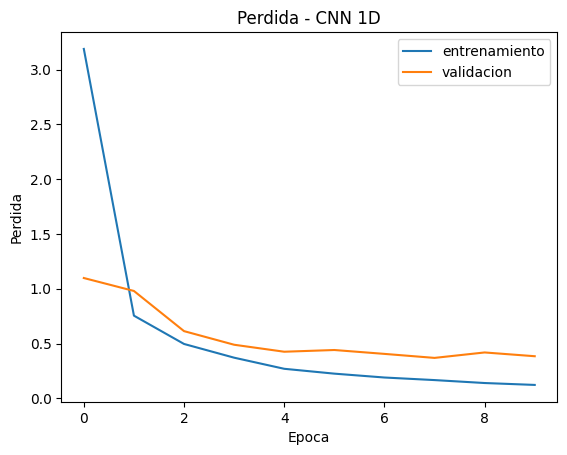

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Resultados - CNN 1D
              precision    recall  f1-score   support

         yes       0.91      0.94      0.93       646
          no       0.90      0.88      0.89       626
          up       0.93      0.93      0.93       590
        down       0.86      0.91      0.88       627
        left       0.85      0.84      0.84       607
       right       0.96      0.91      0.93       604

    accuracy                           0.90      3700
   macro avg       0.90      0.90      0.90      3700
weighted avg       0.90      0.90      0.90      3700

[[606   6   3  12  19   0]
 [  9 549  10  43  14   1]
 [  1   9 548  19  12   1]
 [  4  25  15 571  10   2]
 [ 43  15   7  15 509  18]
 [  1   3   7   6  38 549]]
Epoch 1/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.3945 - loss: 3.5717 - val_accuracy: 0.5705 - val_loss: 1.0577
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.6315 - loss: 0.9401 - val_accuracy:

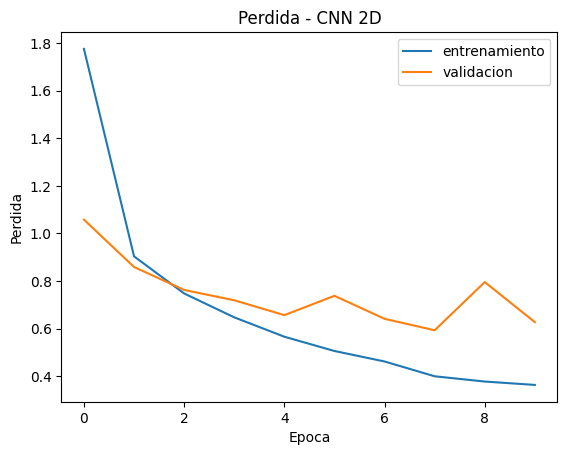

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Resultados - CNN 2D
              precision    recall  f1-score   support

         yes       0.92      0.82      0.86       646
          no       0.69      0.85      0.76       626
          up       0.85      0.74      0.79       590
        down       0.71      0.69      0.70       627
        left       0.71      0.86      0.78       607
       right       0.96      0.79      0.87       604

    accuracy                           0.79      3700
   macro avg       0.81      0.79      0.79      3700
weighted avg       0.81      0.79      0.79      3700

[[528  22  17   1  77   1]
 [ 11 529  17  58  11   0]
 [  5  50 437  78  17   3]
 [  5 153  21 432  16   0]
 [ 24  12  16  18 522  15]
 [  2   4   8  19  94 477]]


In [9]:
# ----------------------
# ENTRENAMIENTO
# ----------------------
def entrenar_y_evaluar(modelo, X_train, y_train, X_val, y_val, titulo):
    modelo.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    historia = modelo.fit(X_train, y_train,
                          validation_data=(X_val, y_val),
                          epochs=10, batch_size=32)

    # grafica d' perdidas
    plt.plot(historia.history['loss'], label='entrenamiento')
    plt.plot(historia.history['val_loss'], label='validacion')
    plt.title(f'Perdida - {titulo}')
    plt.xlabel('Epoca')
    plt.ylabel('Perdida')
    plt.legend()
    plt.show()

    preds = modelo.predict(X_val)
    y_pred = np.argmax(preds, axis=1)
    print(f"Resultados - {titulo}")
    print(classification_report(y_val, y_pred, target_names=CLASES_OBJETIVO))
    print(confusion_matrix(y_val, y_pred))

# main
num_clases = len(CLASES_OBJETIVO)

modelo_rnn = construir_rnn(X_train.shape[1:], num_clases)
entrenar_y_evaluar(modelo_rnn, X_train, y_train, X_val, y_val, "RNN")

modelo_cnn1d = construir_cnn1d(X_train.shape[1:], num_clases)
entrenar_y_evaluar(modelo_cnn1d, X_train, y_train, X_val, y_val, "CNN 1D")

modelo_cnn2d = construir_cnn2d(X_train_2d.shape[1:], num_clases)
entrenar_y_evaluar(modelo_cnn2d, X_train_2d, y_train, X_val_2d, y_val, "CNN 2D")
